# Processamento Digital de Imagens — Laboratório 06
## Vizinhança, Adjacência e Conectividade


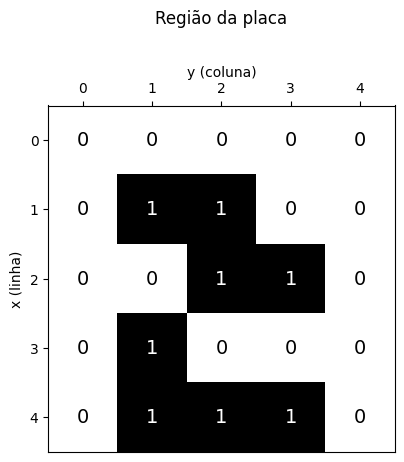

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Matriz da região (1 = cobre)
img = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0],
])
V = {1}
H, W = img.shape

def visualizar(img, destaque=None, titulo="Região da placa", caminho=None):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    for x in range(H):
        for y in range(W):
            ax.text(y, x, str(img[x, y]), ha="center", va="center",
                    color="white" if img[x, y] else "black", fontsize=14)
    if destaque:
        for (x, y) in destaque:
            ax.add_patch(plt.Rectangle((y-.5, x-.5), 1, 1, fill=False, ec="red", lw=3))
    if caminho:
        ax.plot([p[1] for p in caminho], [p[0] for p in caminho], "c-o", lw=3, ms=8)
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.set_xlabel("y (coluna)"); ax.set_ylabel("x (linha)")
    ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
    ax.set_title(titulo, pad=30)
    plt.show()

visualizar(img)

---
## 1. Vizinhança de (2, 2)



Pixel (2, 2), valor = 1

N4 : [((1, 2), 1), ((3, 2), 0), ((2, 1), 0), ((2, 3), 1)]
ND : [((1, 1), 1), ((1, 3), 0), ((3, 1), 1), ((3, 3), 0)]
N8 : [((1, 2), 1), ((3, 2), 0), ((2, 1), 0), ((2, 3), 1), ((1, 1), 1), ((1, 3), 0), ((3, 1), 1), ((3, 3), 0)]

Vizinhos de valor 1 em N4: [(1, 2), (2, 3)]
Vizinhos de valor 1 em N8: [(1, 2), (2, 3), (1, 1), (3, 1)]


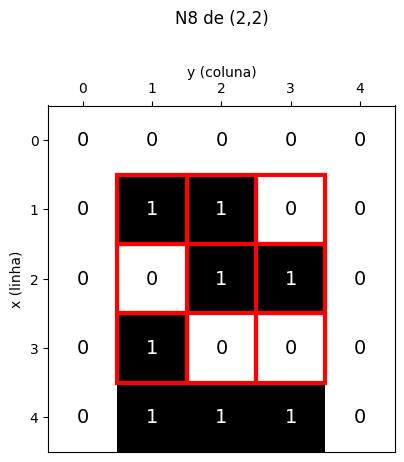

In [2]:
def dentro(p):
    return 0 <= p[0] < H and 0 <= p[1] < W

def N4(p):
    x, y = p
    return [q for q in [(x-1, y), (x+1, y), (x, y-1), (x, y+1)] if dentro(q)]

def ND(p):
    x, y = p
    return [q for q in [(x-1, y-1), (x-1, y+1), (x+1, y-1), (x+1, y+1)] if dentro(q)]

def N8(p):
    return N4(p) + ND(p)

p = (2, 2)
print(f"Pixel {p}, valor = {img[p]}\n")
print("N4 :", [(q, int(img[q])) for q in N4(p)])
print("ND :", [(q, int(img[q])) for q in ND(p)])
print("N8 :", [(q, int(img[q])) for q in N8(p)])
print("\nVizinhos de valor 1 em N4:", [q for q in N4(p) if img[q] in V])
print("Vizinhos de valor 1 em N8:", [q for q in N8(p) if img[q] in V])
visualizar(img, destaque=N8(p), titulo="N8 de (2,2)")

**Resposta 1**

| Vizinhança | Pixels (valor) |
|---|---|
| **N₄(2,2)** | (1,2)=1, (3,2)=0, (2,1)=0, (2,3)=1 |
| **N₈(2,2)** | N₄ + diagonais (1,1)=1, (1,3)=0, (3,1)=1, (3,3)=0 |

Dentro de `V = {1}`, o pixel (2,2) tem 2 vizinhos-4 condutores — (1,2) e (2,3) — e 4 vizinhos-8 condutores — (1,2), (2,3), (1,1) e (3,1).

---
## 2. Adjacência


In [4]:
def adj4(p, q):
    return img[p] in V and img[q] in V and q in N4(p)

def adj8(p, q):
    return img[p] in V and img[q] in V and q in N8(p)

def adjm(p, q, verbose=False):
    if not (img[p] in V and img[q] in V):
        return False
    if q in N4(p):
        return True
    if q in ND(p):
        inter = set(N4(p)) & set(N4(q))
        inter_V = [t for t in inter if img[t] in V]
        if verbose:
            print(f"N4{p} = {N4(p)}")
            print(f"N4{q} = {N4(q)}")
            print(f"N4{p} ∩ N4{q} = {sorted(inter)}")
            print("Valores da interseção:", {t: int(img[t]) for t in sorted(inter)})
            print("Interseção ∩ V =", inter_V)
        return len(inter_V) == 0
    return False

# a) (1,2) e (2,3)
p, q = (1, 2), (2, 3)
print("a) valores:", img[p], img[q])
print("   (2,3) ∈ N4(1,2)?", q in N4(p), "→ N4(1,2) =", N4(p))
print("   Adjacentes-4?", adj4(p, q))
print("   (Adjacentes-8?)", adj8(p, q))

# b) (2,2) e (3,1)
print("\nb) valores:", img[(2,2)], img[(3,1)])
print("   Adjacentes-m?", adjm((2, 2), (3, 1), verbose=True))

a) valores: 1 1
   (2,3) ∈ N4(1,2)? False → N4(1,2) = [(0, 2), (2, 2), (1, 1), (1, 3)]
   Adjacentes-4? False
   (Adjacentes-8?) True

b) valores: 1 1
N4(2, 2) = [(1, 2), (3, 2), (2, 1), (2, 3)]
N4(3, 1) = [(2, 1), (4, 1), (3, 0), (3, 2)]
N4(2, 2) ∩ N4(3, 1) = [(2, 1), (3, 2)]
Valores da interseção: {(2, 1): 0, (3, 2): 0}
Interseção ∩ V = []
   Adjacentes-m? True


**Resposta 2a — (1,2) e (2,3) NÃO são adjacentes-4.**
Ambos valem 1 (pertencem a V), mas estão em posição **diagonal** (Δx = 1, Δy = 1). Como N₄(1,2) = {(0,2), (2,2), (1,1), (1,3)}, o pixel (2,3) não pertence à vizinhança-4 de (1,2). Eles são apenas adjacentes-8.

**Resposta 2b — (2,2) e (3,1) SÃO adjacentes-m.**
Ambos valem 1 e (3,1) ∈ N_D(2,2) (diagonal). Análise da interseção:
- N₄(2,2) = {(1,2), (3,2), (2,1), (2,3)}
- N₄(3,1) = {(2,1), (4,1), (3,0), (3,2)}
- N₄(2,2) ∩ N₄(3,1) = {(2,1), (3,2)}, com valores 0 e 0

Nenhum pixel da interseção pertence a V = {1}, ou seja, **N₄(2,2) ∩ N₄(3,1) ∩ V = ∅**; logo a condição de adjacência-m é satisfeita.

---
## 3. Caminho e curto-circuito


Caminho-8 entre (1,1) e (4,1): [(1, 1), (2, 2), (3, 1), (4, 1)] | comprimento = 3
Caminho-4 entre (1,1) e (4,1): None


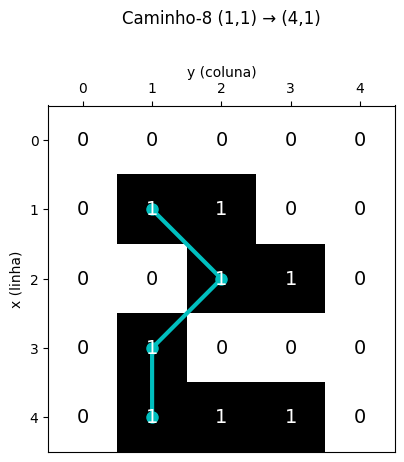


Componentes com 4-conectividade: 2
[[0 0 0 0 0]
 [0 1 1 0 0]
 [0 0 1 1 0]
 [0 2 0 0 0]
 [0 2 2 2 0]]

Componentes com 8-conectividade: 1
[[0 0 0 0 0]
 [0 1 1 0 0]
 [0 0 1 1 0]
 [0 1 0 0 0]
 [0 1 1 1 0]]


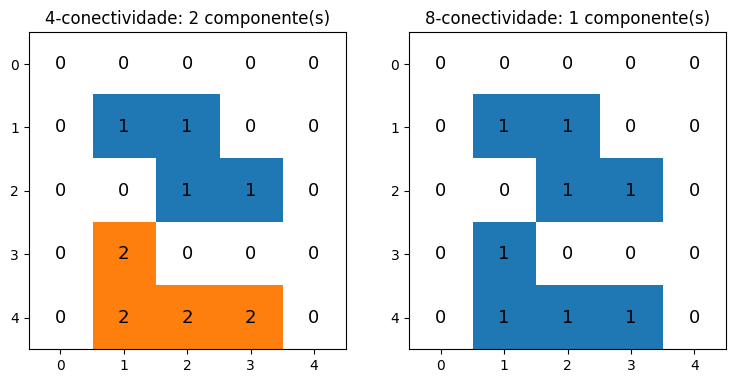


Curto-circuito sob 8-conectividade? SIM


In [5]:
def bfs(origem, destino, vizinhanca):
    if img[origem] not in V or img[destino] not in V:
        return None
    fila = deque([origem])
    pai = {origem: None}
    while fila:
        atual = fila.popleft()
        if atual == destino:
            caminho = []
            while atual is not None:
                caminho.append(atual)
                atual = pai[atual]
            return caminho[::-1]
        for viz in vizinhanca(atual):
            if img[viz] in V and viz not in pai:
                pai[viz] = atual
                fila.append(viz)
    return None

a, b = (1, 1), (4, 1)
c8 = bfs(a, b, N8)
c4 = bfs(a, b, N4)

print("Caminho-8 entre (1,1) e (4,1):", c8, "| comprimento =", len(c8)-1 if c8 else None)
print("Caminho-4 entre (1,1) e (4,1):", c4)

visualizar(img, caminho=c8, titulo="Caminho-8 (1,1) → (4,1)")

# Componentes conexos (rotulagem) sob cada conectividade
def componentes(vizinhanca):
    rotulos = np.zeros_like(img)
    n = 0
    for x in range(H):
        for y in range(W):
            if img[x, y] in V and rotulos[x, y] == 0:
                n += 1
                fila = deque([(x, y)]); rotulos[x, y] = n
                while fila:
                    cur = fila.popleft()
                    for v in vizinhanca(cur):
                        if img[v] in V and rotulos[v] == 0:
                            rotulos[v] = n; fila.append(v)
    return rotulos, n

r4, n4 = componentes(N4)
r8, n8 = componentes(N8)
print(f"\nComponentes com 4-conectividade: {n4}\n{r4}")
print(f"\nComponentes com 8-conectividade: {n8}\n{r8}")

fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, r, n, t in [(axs[0], r4, n4, "4-conectividade"), (axs[1], r8, n8, "8-conectividade")]:
    ax.imshow(np.ma.masked_where(r == 0, r), cmap="tab10", vmin=1, vmax=10)
    for x in range(H):
        for y in range(W):
            ax.text(y, x, str(r[x, y]), ha="center", va="center", fontsize=13)
    ax.set_title(f"{t}: {n} componente(s)")
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
plt.show()

print("\nCurto-circuito sob 8-conectividade?", "SIM" if c8 else "NÃO")

**Resposta 3**

- **Existe caminho-8** entre (1,1) e (4,1):
  **(1,1) → (2,2) → (3,1) → (4,1)** — todos os pixels valem 1 e cada par consecutivo é 8-adjacente (as duas primeiras passagens são diagonais). Comprimento = 3.
- **Sob 8-conectividade há curto-circuito:** a trilha superior e a inferior formam um único componente conexo, ou seja, o software as considera eletricamente ligadas através das diagonais (2,2)–(3,1).
- Observação: sob 4-conectividade **não** existe caminho (são 2 componentes separados), pois (3,1) não tem nenhum vizinho-4 com valor 1 além de (4,1). Portanto o "curto" só aparece por causa da conexão diagonal. Para evitar esse falso positivo/ambiguidade, pode-se usar a **m-conectividade**.

---
## 4. Medidas de distância


In [6]:
def D4(p, q):
    return abs(p[0] - q[0]) + abs(p[1] - q[1])

def D8(p, q):
    return max(abs(p[0] - q[0]), abs(p[1] - q[1]))

p, q = (1, 1), (4, 3)
print(f"Δx = {abs(p[0]-q[0])}, Δy = {abs(p[1]-q[1])}")
print(f"D4({p}, {q}) = {abs(p[0]-q[0])} + {abs(p[1]-q[1])} = {D4(p, q)}")
print(f"D8({p}, {q}) = max({abs(p[0]-q[0])}, {abs(p[1]-q[1])}) = {D8(p, q)}")

Δx = 3, Δy = 2
D4((1, 1), (4, 3)) = 3 + 2 = 5
D8((1, 1), (4, 3)) = max(3, 2) = 3


**Resposta 4** — entre (1,1) e (4,3): Δx = 3 e Δy = 2

- **D₄ = 3 + 2 = 5**
- **D₈ = max(3, 2) = 3**

(Sempre vale D₈ ≤ D₄, pois a diagonal permite "cortar caminho".)

---
## Resumo final
| Questão | Resultado |
|---|---|
| 1. N₄(2,2) | (1,2), (3,2), (2,1), (2,3) |
| 1. N₈(2,2) | N₄ + (1,1), (1,3), (3,1), (3,3) |
| 2a. (1,2) e (2,3) adjacentes-4? | **Não** (são diagonais) |
| 2b. (2,2) e (3,1) adjacentes-m? | **Sim** (N₄ ∩ N₄ = {(2,1),(3,2)} sem pixels de V) |
| 3. Caminho-8 (1,1)→(4,1) | **Sim**: (1,1),(2,2),(3,1),(4,1) |
| 3. Curto-circuito (8-conectividade)? | **Sim** |
| 4. D₄ / D₈ entre (1,1) e (4,3) | **5** / **3** |